# CCR2 Virtual Screening Benchmark

This notebook compares multiple pharmacophore-based virtual screening approaches
for CCR2 ligand discovery. We evaluate different scoring methods and measure:

- **ROC-AUC**: Overall discrimination ability
- **BEDROC**: Early recognition (top ~8%)
- **Enrichment Factors**: EF@1%, EF@5%, EF@10%
- **Youden's Index**: Optimal threshold selection
- **Timing**: Speed (ms/molecule)

In [1]:
# Import libraries
import time
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

# Pharmacophore toolkit
from pharmacophore import (
    Pharmacophore, PharmacophoreConsensus, PharmacophoreToMol,
    ConsensusOptimizer, youden_index, bedroc, rie,
    enrichment_factor, screening_report, calculate_all_metrics
)
from pharmacophore.benchmark import ScreeningBenchmark

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load CCR2 Dataset

- **Reference ligands**: 5 known CCR2 ligands for consensus pharmacophore
- **Actives**: 75 CCR2 active compounds
- **Decoys**: 500 decoy compounds

In [2]:
# Load reference ligands
ref_mols = [m for m in Chem.SDMolSupplier('data/CCR2_reference_ligands.sdf') if m]
print(f"Reference ligands: {len(ref_mols)}")

# Load actives
actives_df = pd.read_csv('data/actives_ccr2_N75.csv')
actives = []
for smi in actives_df['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, randomSeed=42)
        actives.append(mol)
print(f"Active compounds: {len(actives)}")

# Load decoys
decoys_df = pd.read_csv('data/decoys_ccr2_N500.csv')
decoys = []
for smi in decoys_df['Smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, randomSeed=42)
        decoys.append(mol)
print(f"Decoy compounds: {len(decoys)}")

print(f"\nTotal compounds to screen: {len(actives) + len(decoys)}")
print(f"Active ratio: {len(actives)/(len(actives)+len(decoys)):.2%}")

Reference ligands: 5
Active compounds: 74
Decoy compounds: 498

Total compounds to screen: 572
Active ratio: 12.94%


## 2. Generate Consensus Pharmacophore

In [3]:
# Generate consensus pharmacophore
consensus = PharmacophoreConsensus(
    tolerance=2.0,
    occurrence_threshold=0.5,
    linkage='average'
)

features = consensus.generate_consensus(ref_mols)
print(f"Consensus features: {len(features)}")

# Display features
for f in features:
    print(f"  {f[0]:15} @ ({f[2]:.2f}, {f[3]:.2f}, {f[4]:.2f})")

# Convert to RDKit mol for scoring
pharm_mol = PharmacophoreToMol.convert(features, enable_color_features=True)
print(f"\nPharmacophore mol atoms: {pharm_mol.GetNumAtoms()}")

Consensus features: 7
  Acceptor        @ (2.99, 28.93, 187.76)
  Acceptor        @ (3.64, 25.76, 191.27)
  Acceptor        @ (2.11, 27.72, 190.03)
  Aromatic        @ (3.66, 26.16, 191.11)
  Aromatic        @ (6.44, 30.39, 185.75)
  Hydrophobe      @ (7.96, 32.25, 184.58)
  Hydrophobe      @ (7.49, 24.88, 184.70)

Pharmacophore mol atoms: 66


## 3. Run Benchmark: Compare Scoring Methods

We compare 3 scoring approaches:
1. **Combo (shape+color)**: Current default method
2. **Shape Only**: Pure 3D shape similarity
3. **Color Weighted**: 0.3×shape + 0.7×color (pharmacophore emphasized)

In [4]:
# Initialize benchmark
benchmark = ScreeningBenchmark(
    reference_mols=ref_mols,
    actives=actives,
    decoys=decoys,
    n_conformers=10,
    random_state=42
)

print("Running benchmark on all methods...")
print("="*60)

# Run all standard methods
benchmark.run_all_standard_methods(
    tolerance=2.0,
    occurrence_threshold=0.5,
    verbose=True
)

print("="*60)
print("Benchmark complete!")

Running benchmark on all methods...
Running Pharm2D Tanimoto... AUC=0.858, EF@1%=7.7, time=14.9ms/mol
Running Reference Alignment... AUC=0.897, EF@1%=7.7, time=203.5ms/mol
Running Combo (shape+color)... AUC=0.326, EF@1%=0.0, time=12.9ms/mol
Running Shape Only... AUC=0.336, EF@1%=0.0, time=17.0ms/mol
Running Color Weighted (0.3/0.7)... AUC=0.384, EF@1%=0.0, time=18.4ms/mol
Benchmark complete!


## 4. Comparison Table

In [5]:
# Generate comparison table
comparison = benchmark.comparison_table()

# Display with formatting
pd.set_option('display.precision', 3)
display(comparison.style.format({
    'ROC-AUC': '{:.3f}',
    'BEDROC': '{:.3f}',
    'EF@1%': '{:.1f}',
    'EF@5%': '{:.1f}',
    'EF@10%': '{:.1f}',
    'Youden J': '{:.3f}',
    'Threshold': '{:.3f}',
    'Sensitivity': '{:.3f}',
    'Specificity': '{:.3f}',
    'Time (ms/mol)': '{:.1f}'
}).background_gradient(subset=['ROC-AUC', 'BEDROC', 'EF@1%'], cmap='Greens'))

,Method,ROC-AUC,BEDROC,EF@1%,EF@5%,EF@10%,Youden J,Threshold,Sensitivity,Specificity,Time (ms/mol)
0,Reference Alignment,0.897,0.850,7.7,7.7,5.8,0.657,0.423,0.838,0.819,203.5
1,Pharm2D Tanimoto,0.858,0.713,7.7,6.9,4.1,0.597,0.239,0.932,0.665,14.9
2,Color Weighted (0.3/0.7),0.384,0.018,0.0,0.0,0.1,0.003,0.190,0.986,0.016,18.4
3,Shape Only,0.336,0.023,0.0,0.0,0.3,0.017,0.457,0.973,0.044,17.0
4,Combo (shape+color),0.326,0.004,0.0,0.0,0.0,0.004,0.231,1.000,0.004,12.9


## 5. Visualizations

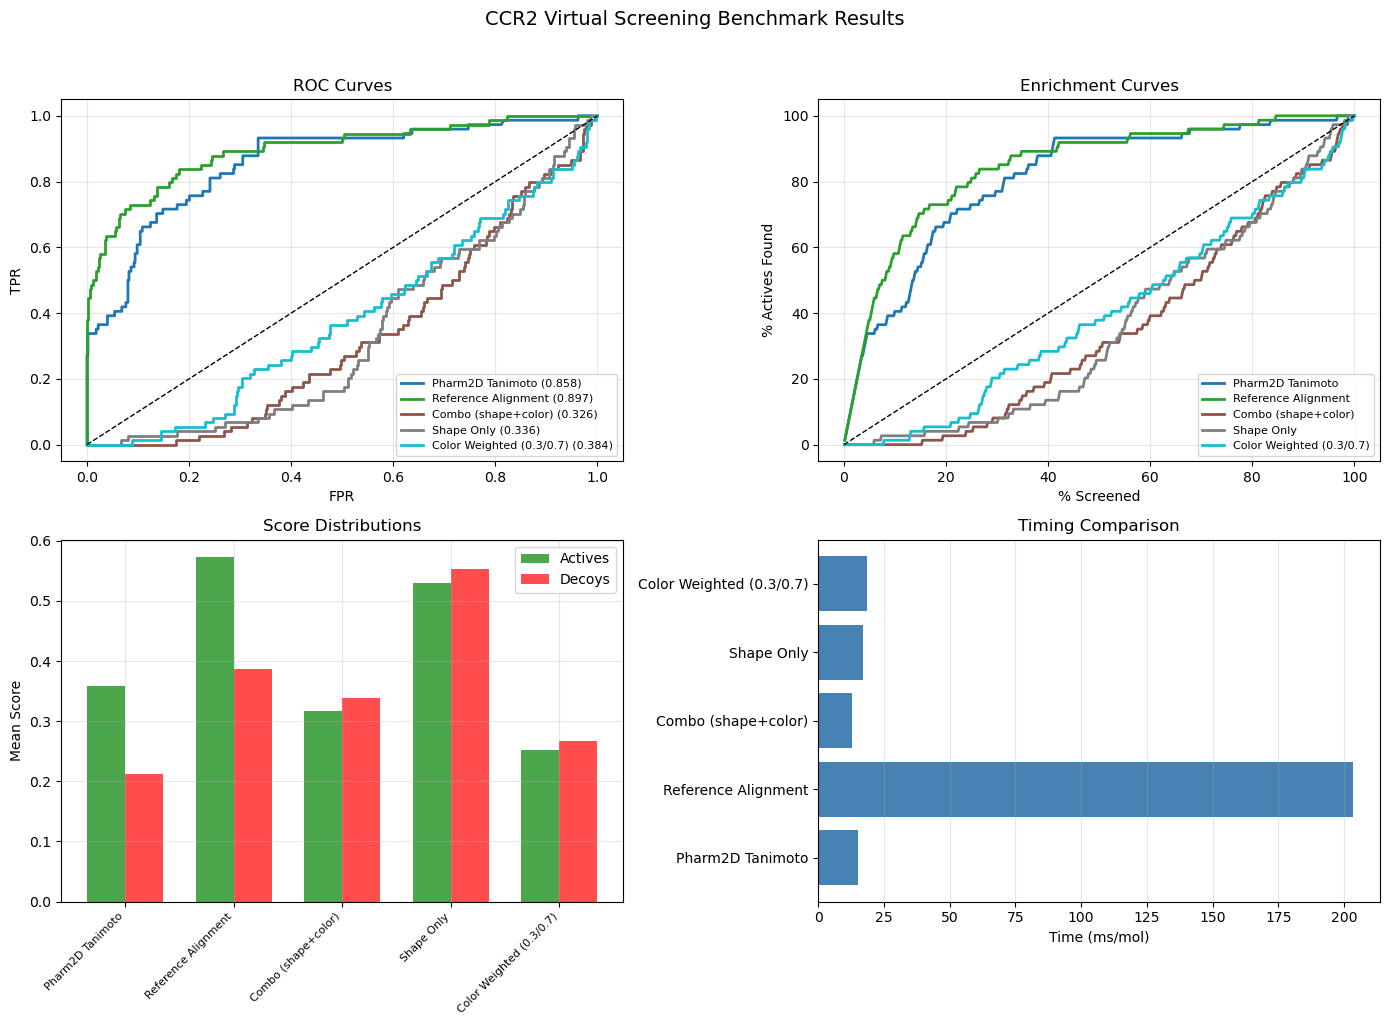

In [6]:
# Create 4-panel visualization
fig = benchmark.plot_all(figsize=(14, 10))
plt.suptitle('CCR2 Virtual Screening Benchmark Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ccr2_benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()

### ROC Curves

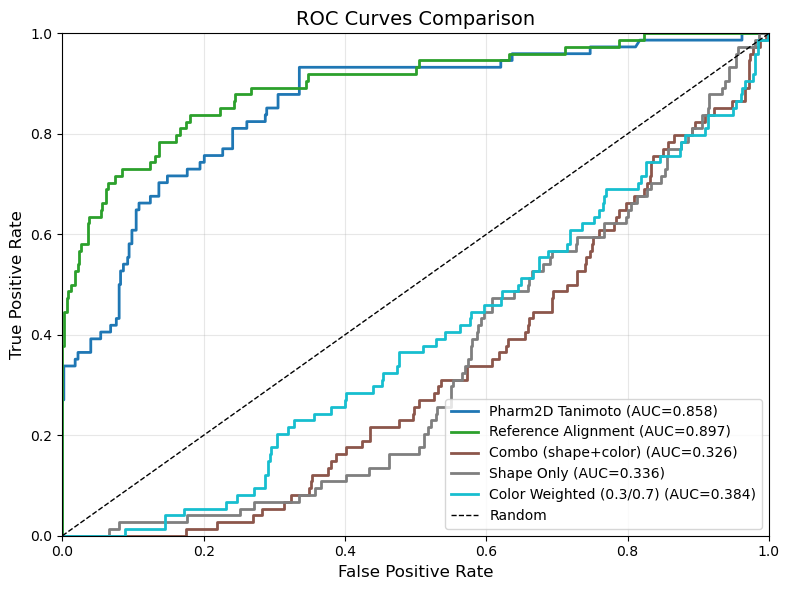

In [7]:
fig = benchmark.plot_roc_curves(figsize=(8, 6))
plt.show()

### Enrichment Curves

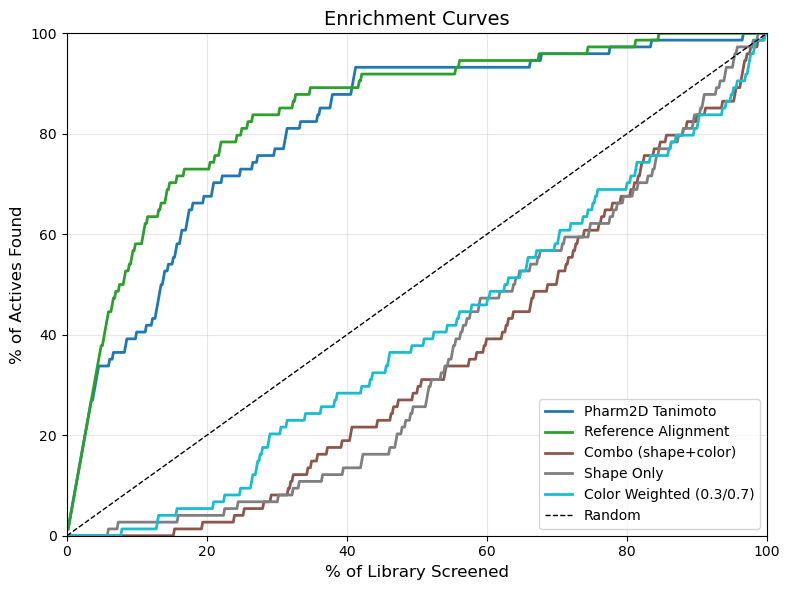

In [8]:
fig = benchmark.plot_enrichment_curves(figsize=(8, 6))
plt.show()

### Score Distributions

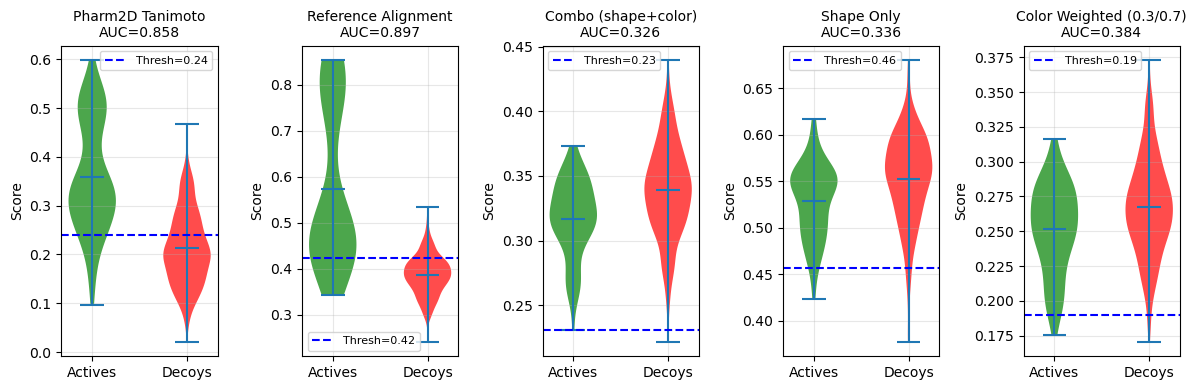

In [9]:
fig = benchmark.plot_score_distributions(figsize=(12, 4))
plt.show()

## 6. Detailed Screening Report

Full metrics for the best-performing method.

In [10]:
# Get the best method based on ROC-AUC
best_method = comparison.iloc[0]['Method']
best_result = benchmark.results[best_method]

print(f"Best Method: {best_method}")
print("="*50)

# Generate full screening report
y_true = benchmark.y_true
y_scores = best_result['scores']

report = screening_report(y_true, y_scores)
display(report)

Best Method: Reference Alignment


,Metric,Value
0,N Total,572.000
1,N Actives,74.000
2,N Decoys,498.000
3,Active Ratio,0.129
4,ROC-AUC,0.897
5,BEDROC (α=20),0.850
6,BEDROC (α=80.5),0.992
7,RIE (α=20),6.076
8,EF@1%,7.730
9,EF@5%,7.730


## 7. Youden's Index Analysis

Find the optimal score threshold for classification.

Optimal Threshold: 0.423
Youden's J:        0.657
Sensitivity:       0.838
Specificity:       0.819


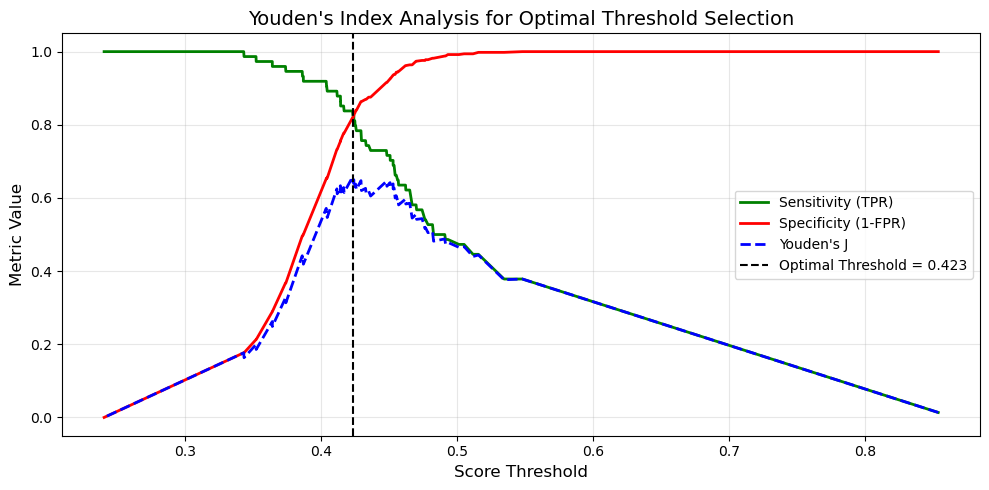

In [11]:
from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Calculate Youden's J for each threshold
youden_j_values = tpr - fpr
optimal_idx = np.argmax(youden_j_values)

optimal_thresh = thresholds[optimal_idx]
optimal_sens = tpr[optimal_idx]
optimal_spec = 1 - fpr[optimal_idx]
optimal_j = youden_j_values[optimal_idx]

print(f"Optimal Threshold: {optimal_thresh:.3f}")
print(f"Youden's J:        {optimal_j:.3f}")
print(f"Sensitivity:       {optimal_sens:.3f}")
print(f"Specificity:       {optimal_spec:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, tpr[:-1] if len(tpr) > len(thresholds) else tpr, 
        'g-', linewidth=2, label='Sensitivity (TPR)')
ax.plot(thresholds, 1 - fpr[:-1] if len(fpr) > len(thresholds) else 1 - fpr, 
        'r-', linewidth=2, label='Specificity (1-FPR)')
ax.plot(thresholds, youden_j_values[:-1] if len(youden_j_values) > len(thresholds) else youden_j_values, 
        'b--', linewidth=2, label="Youden's J")

ax.axvline(x=optimal_thresh, color='k', linestyle='--', 
           label=f'Optimal Threshold = {optimal_thresh:.3f}')

ax.set_xlabel('Score Threshold', fontsize=12)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title("Youden's Index Analysis for Optimal Threshold Selection", fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary and Recommendations

In [12]:
print("="*60)
print("BENCHMARK SUMMARY")
print("="*60)

# Best by each metric
print("\nBest Method by Metric:")
print("-"*40)

metrics = ['ROC-AUC', 'BEDROC', 'EF@1%', 'EF@5%']
for metric in metrics:
    best_idx = comparison[metric].idxmax()
    best_method = comparison.loc[best_idx, 'Method']
    best_value = comparison.loc[best_idx, metric]
    print(f"  {metric:12}: {best_method:25} ({best_value:.3f})")

# Fastest method
fastest_idx = comparison['Time (ms/mol)'].idxmin()
print(f"  {'Fastest':12}: {comparison.loc[fastest_idx, 'Method']:25} ({comparison.loc[fastest_idx, 'Time (ms/mol)']:.1f} ms/mol)")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)

# Overall recommendation
best_overall = comparison.iloc[0]
print(f"\nRecommended Method: {best_overall['Method']}")
print(f"  - ROC-AUC: {best_overall['ROC-AUC']:.3f}")
print(f"  - BEDROC:  {best_overall['BEDROC']:.3f}")
print(f"  - EF@1%:   {best_overall['EF@1%']:.1f}x enrichment")
print(f"  - Optimal threshold: {best_overall['Threshold']:.3f}")

print("\nConclusion:")
if best_overall['ROC-AUC'] > 0.7:
    print("  Good discrimination between actives and decoys.")
if best_overall['BEDROC'] > 0.5:
    print("  Strong early recognition - actives enriched at top of ranked list.")
if best_overall['EF@1%'] > 5:
    print("  Excellent enrichment at 1% - suitable for experimental follow-up.")

BENCHMARK SUMMARY

Best Method by Metric:
----------------------------------------
  ROC-AUC     : Reference Alignment       (0.897)
  BEDROC      : Reference Alignment       (0.850)
  EF@1%       : Reference Alignment       (7.730)
  EF@5%       : Reference Alignment       (7.730)
  Fastest     : Combo (shape+color)       (12.9 ms/mol)

RECOMMENDATIONS

Recommended Method: Reference Alignment
  - ROC-AUC: 0.897
  - BEDROC:  0.850
  - EF@1%:   7.7x enrichment
  - Optimal threshold: 0.423

Conclusion:
  Good discrimination between actives and decoys.
  Strong early recognition - actives enriched at top of ranked list.
  Excellent enrichment at 1% - suitable for experimental follow-up.


---

## Appendix: Save Results

In [13]:
# Save comparison table to CSV
comparison.to_csv('ccr2_benchmark_comparison.csv', index=False)
print("Saved: ccr2_benchmark_comparison.csv")

# Save detailed report
report.to_csv('ccr2_screening_report.csv', index=False)
print("Saved: ccr2_screening_report.csv")

print("\nBenchmark complete!")

Saved: ccr2_benchmark_comparison.csv
Saved: ccr2_screening_report.csv

Benchmark complete!
